# Phishing Text Classifier — XLM-RoBERTa (Kaggle + html.xlsx)

This notebook trains an **XLM-RoBERTa** (multilingual) model for **phishing vs benign** classification using webpage content from `html.xlsx`.

**Input dataset**: `html.xlsx` — uploaded as a Kaggle Dataset.
Expected columns:

| Column | Description |
|--------|-------------|
| `Category` | `spam` (phishing) or `ham` (benign) |
| `Data` | Raw HTML content of the webpage |

**Output reports**: training/validation curves, feature correlation heatmap, confusion matrix, ROC/PR curve, classification report (precision/recall/F1) and the model files saved to `/kaggle/working/`.

## 1. Setup Kaggle environment

In [1]:
import os, sys

# Check GPU
!nvidia-smi || echo 'No GPU detected. Please enable GPU in Kaggle settings.'

# Install necessary libraries
!pip -q install --upgrade transformers accelerate datasets scikit-learn beautifulsoup4 lxml pandas matplotlib seaborn

print('\n>>> Setup completed.')

Tue Jun  9 23:13:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Configure dataset & model output paths (Kaggle)

In [2]:
from pathlib import Path

# --- IMPORTANT: Update the path below to match your Kaggle Dataset name ---
# After uploading html.xlsx as a Kaggle Dataset (e.g. 'phishing-html-data'),
# the file will be available at /kaggle/input/<dataset-name>/html.xlsx
XLSX_PATH = Path('/kaggle/input/datasets/lewischu1909/phishing-html-data/html.xlsx')

# Output directories
OUTPUT_MODEL_DIR = Path('/kaggle/working/models/xlmr_phishing')
OUTPUT_REPORT_DIR = Path('/kaggle/working/reports/xlmr_phishing')
OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Verify input
assert XLSX_PATH.exists(), f'File not found: {XLSX_PATH}. Check your Kaggle Dataset path!'
print(f'>>> Input file: {XLSX_PATH} ({XLSX_PATH.stat().st_size / 1024 / 1024:.0f} MB)')
print(f'>>> Model output: {OUTPUT_MODEL_DIR}')
print(f'>>> Report output: {OUTPUT_REPORT_DIR}')

>>> Input file: /kaggle/input/datasets/lewischu1909/phishing-html-data/html.xlsx (207 MB)
>>> Model output: /kaggle/working/models/xlmr_phishing
>>> Report output: /kaggle/working/reports/xlmr_phishing


## 3. Load + clean data from html.xlsx

This section reads `html.xlsx`, extracts phishing signals from raw HTML using BeautifulSoup, and builds `text_combined` — the input format for XLM-RoBERTa.

Signals extracted: `<title>`, `<meta>`, anchor text, input fields, form actions, and visible text.

Label mapping: `spam` → 1 (phishing), `ham` → 0 (benign).

In [3]:
import re
import pandas as pd
from bs4 import BeautifulSoup
from concurrent.futures import ProcessPoolExecutor, as_completed
import time

# --- Label mapping ---
LABEL_MAP = {'spam': 1, 'ham': 0}
MAX_HTML_BYTES = 2_000_000

# --- Helper functions ---
def clean_whitespace(s: str) -> str:
    return re.sub(r'\s+', ' ', s).strip()

def extract_signals_from_html(html: str) -> dict:
    """Extract semantically rich signals from HTML for phishing detection."""
    soup = BeautifulSoup(html, 'lxml')
    for tag in soup(['script', 'style', 'noscript']):
        tag.extract()
    title = soup.title.string if soup.title and soup.title.string else ''
    metas = []
    for m in soup.find_all('meta'):
        name = m.get('name') or m.get('property') or ''
        content = m.get('content') or ''
        if content:
            metas.append(f'{name}={content}')
    anchors = [a.get_text(' ', strip=True) for a in soup.find_all('a')]
    inputs = []
    for inp in soup.find_all('input'):
        inputs.append('|'.join([
            f"type={inp.get('type','')}",
            f"name={inp.get('name','')}",
            f"placeholder={inp.get('placeholder','')}",
            f"id={inp.get('id','')}",
        ]))
    forms = []
    for f in soup.find_all('form'):
        forms.append(f"form_action={f.get('action','')} method={f.get('method','')}")
    visible = soup.get_text(' ', strip=True)
    return {
        'title': clean_whitespace(title or ''),
        'meta': clean_whitespace(' | '.join(metas)),
        'anchors': clean_whitespace(' '.join(anchors))[:5000],
        'inputs': clean_whitespace(' '.join(inputs)),
        'forms': clean_whitespace(' '.join(forms)),
        'visible': clean_whitespace(visible)[:20000],
    }

def process_row(args):
    """Process a single row from the Excel file."""
    idx, category, html_data = args
    label = LABEL_MAP.get(category)
    if label is None:
        return None
    html_str = str(html_data)[:MAX_HTML_BYTES] if html_data else ''
    try:
        signals = extract_signals_from_html(html_str)
    except Exception:
        signals = {'title': '', 'meta': '', 'anchors': '', 'inputs': '', 'forms': '', 'visible': ''}
    text_combined = clean_whitespace(' \n '.join([
        f"<title> {signals['title']}",
        f"<meta> {signals['meta']}",
        f"<forms> {signals['forms']}",
        f"<inputs> {signals['inputs']}",
        f"<anchors> {signals['anchors']}",
        f"<text> {signals['visible']}",
    ]))
    return {
        'file_id': f'{label}_{idx}',
        'label': label,
        'text_extracted': signals.get('visible', '')[:10000],
        **signals,
        'text_combined': text_combined,
    }

# --- Step 1: Read Excel ---
print('>>> Reading html.xlsx ...')
t0 = time.time()
df_raw = pd.read_excel(XLSX_PATH, engine='openpyxl')
print(f'    Read {len(df_raw)} rows in {time.time() - t0:.1f}s')
print(f'    Categories: {df_raw["Category"].value_counts().to_dict()}')

# --- Step 2: Extract signals (parallel) ---
print('\n>>> Extracting signals from HTML (parallel processing) ...')
t0 = time.time()
tasks = [(i, row['Category'], row['Data']) for i, row in df_raw.iterrows()]
results = []
done = 0
total = len(tasks)

with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(process_row, task): task for task in tasks}
    for future in as_completed(futures):
        result = future.result()
        if result is not None:
            results.append(result)
        done += 1
        if done % 2000 == 0 or done == total:
            elapsed = time.time() - t0
            rate = done / elapsed if elapsed > 0 else 0
            eta = (total - done) / rate if rate > 0 else 0
            print(f'    {done}/{total} ({done*100//total}%) - {rate:.0f} rows/s - ETA: {eta:.0f}s')

# --- Step 3: Build DataFrame ---
df = pd.DataFrame(results)
print(f'\n>>> Total rows: {len(df)}')
print('    Label distribution:')
print(df['label'].value_counts().rename({0: 'benign(0)', 1: 'phishing(1)'}))
df.head(2)

>>> Reading html.xlsx ...
    Read 45373 rows in 15.5s
    Categories: {'ham': 22687, 'spam': 22686}

>>> Extracting signals from HTML (parallel processing) ...


/tmp/ipykernel_22/729351922.py:17: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(html, 'lxml')
/tmp/ipykernel_22/729351922.py:17: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but yo

    2000/45373 (4%) - 125 rows/s - ETA: 346s
    4000/45373 (8%) - 196 rows/s - ETA: 211s
    6000/45373 (13%) - 243 rows/s - ETA: 162s
    8000/45373 (17%) - 275 rows/s - ETA: 136s
    10000/45373 (22%) - 300 rows/s - ETA: 118s
    12000/45373 (26%) - 318 rows/s - ETA: 105s
    14000/45373 (30%) - 333 rows/s - ETA: 94s
    16000/45373 (35%) - 344 rows/s - ETA: 85s
    18000/45373 (39%) - 356 rows/s - ETA: 77s
    20000/45373 (44%) - 364 rows/s - ETA: 70s
    22000/45373 (48%) - 371 rows/s - ETA: 63s
    24000/45373 (52%) - 378 rows/s - ETA: 56s
    26000/45373 (57%) - 384 rows/s - ETA: 51s
    28000/45373 (61%) - 389 rows/s - ETA: 45s
    30000/45373 (66%) - 394 rows/s - ETA: 39s
    32000/45373 (70%) - 398 rows/s - ETA: 34s
    34000/45373 (74%) - 402 rows/s - ETA: 28s
    36000/45373 (79%) - 406 rows/s - ETA: 23s
    38000/45373 (83%) - 409 rows/s - ETA: 18s
    40000/45373 (88%) - 411 rows/s - ETA: 13s
    42000/45373 (92%) - 413 rows/s - ETA: 8s
    44000/45373 (96%) - 415 rows/s 

,file_id,label,text_extracted,title,meta,anchors,inputs,forms,visible,text_combined
0,1_2,1,,,=0;url=http://error.talktalk.co.uk/main?Partic...,,,,,<title> <meta> =0;url=http://error.talktalk.co...
1,1_3,1,',,=1; URL=\'https://segurancaitauonline.com/segc...,,,,',<title> <meta> =1; URL=\'https://segurancaitau...


## 4. EDA: Label distribution, text length, feature correlation heatmap

The heatmap is plotted between **numeric features** extracted from HTML (number of forms, inputs, presence of password field, text length, presence of IP, @, etc.) — these traditional features remain very effective for phishing detection.

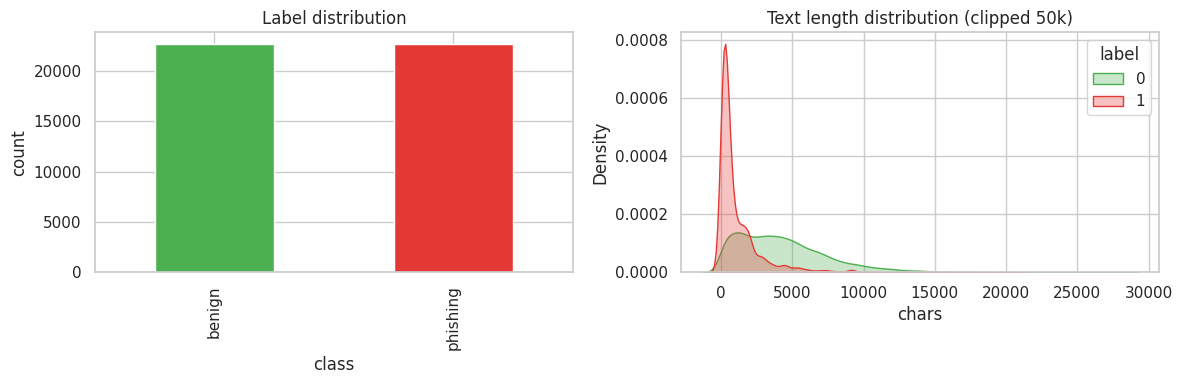

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().sort_index().rename({0: 'benign', 1: 'phishing'}).plot(kind='bar', ax=axes[0], color=['#4caf50', '#e53935'])
axes[0].set_title('Label distribution')
axes[0].set_xlabel('class')
axes[0].set_ylabel('count')
df['text_len'] = df['text_combined'].str.len()
for lab, color in [(0, '#4caf50'), (1, '#e53935')]:
    sns.kdeplot(df.loc[df.label == lab, 'text_len'].clip(upper=50000), ax=axes[1], label=str(lab), fill=True, alpha=0.3, color=color)
axes[1].set_title('Text length distribution (clipped 50k)')
axes[1].set_xlabel('chars')
axes[1].legend(title='label')
plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'eda_label_textlen.png', dpi=150)
plt.show()

/tmp/ipykernel_22/3319910941.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_login_kw': df['text_combined'].str.contains(r'(login|sign in|signin|verify|password)', case=False, regex=True).astype(int),
/tmp/ipykernel_22/3319910941.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_bank_kw': df['text_combined'].str.contains(r'(bank|paypal|secure|account|wallet)', case=False, regex=True).astype(int),


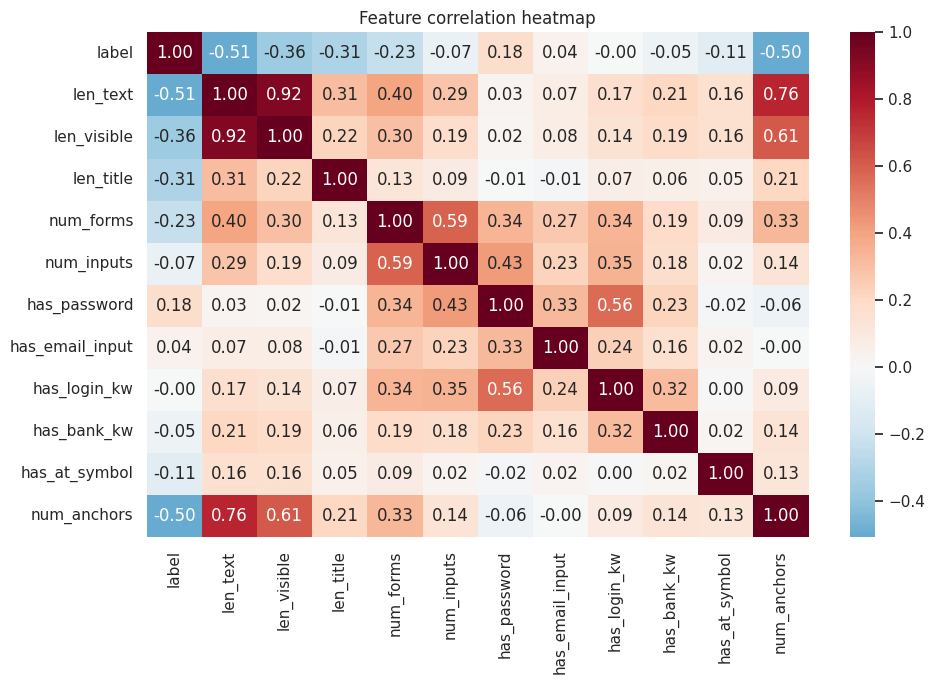

In [5]:
feat = pd.DataFrame({
    'label': df['label'],
    'len_text': df['text_combined'].str.len(),
    'len_visible': df['visible'].str.len(),
    'len_title': df['title'].str.len(),
    'num_forms': df['forms'].str.count('form_action='),
    'num_inputs': df['inputs'].str.count('type='),
    'has_password': df['inputs'].str.contains('type=password', case=False, regex=False).astype(int),
    'has_email_input': df['inputs'].str.contains('type=email', case=False, regex=False).astype(int),
    'has_login_kw': df['text_combined'].str.contains(r'(login|sign in|signin|verify|password)', case=False, regex=True).astype(int),
    'has_bank_kw': df['text_combined'].str.contains(r'(bank|paypal|secure|account|wallet)', case=False, regex=True).astype(int),
    'has_at_symbol': df['anchors'].str.contains('@', regex=False).astype(int),
    'num_anchors': df['anchors'].str.count(' '),
})

corr = feat.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'feature_correlation_heatmap.png', dpi=150)
plt.show()

## 5. Train/Val/Test split (stratified) and class imbalance handling
- **Stratified 70/15/15** split.
- Calculate `class_weights` for the loss function to reduce bias towards the majority phishing class.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

df = df[df['text_combined'].str.len() > 20].reset_index(drop=True)
print('Rows after empty filter:', len(df))

train_df, tmp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(tmp_df, test_size=0.50, random_state=42, stratify=tmp_df['label'])
print('train/val/test:', len(train_df), len(val_df), len(test_df))
print('train labels:', train_df['label'].value_counts().to_dict())
print('val labels:', val_df['label'].value_counts().to_dict())
print('test labels:', test_df['label'].value_counts().to_dict())

import numpy as np
class_weights_np = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df['label'].values)
print('class_weights:', class_weights_np)

Rows after empty filter: 45373
train/val/test: 31761 6806 6806
train labels: {0: 15881, 1: 15880}
val labels: {0: 3403, 1: 3403}
test labels: {0: 3403, 1: 3403}
class_weights: [0.99996852 1.00003149]


## 6. Tokenization with XLM-RoBERTa

Using `xlm-roberta-base` (multilingual). `max_length=256` balances speed and quality for webpage text after cleaning and prefixing with signal tags (`<title>`, `<forms>`, etc.).

In [7]:
import torch
from transformers import AutoTokenizer

MODEL_NAME = 'xlm-roberta-base'
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(list(texts), truncation=True, padding=True, max_length=MAX_LEN)

train_enc = tokenize(train_df['text_combined'])
val_enc = tokenize(val_df['text_combined'])
test_enc = tokenize(test_df['text_combined'])

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(int(self.labels[i]))
        return item

train_ds = TextDataset(train_enc, train_df['label'])
val_ds = TextDataset(val_enc, val_df['label'])
test_ds = TextDataset(test_enc, test_df['label'])
print('Tokenize OK. sizes:', len(train_ds), len(val_ds), len(test_ds))

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenize OK. sizes: 31761 6806 6806


## 7. Train XLM-RoBERTa with Trainer (weighted loss)

In [8]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

class_weights_t = torch.tensor(class_weights_np, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_t.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0),
        'roc_auc': roc_auc_score(labels, probs) if len(set(labels)) > 1 else float('nan'),
    }

args = TrainingArguments(
    output_dir='/kaggle/working/results_xlmr',
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
print(train_result)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.106463,0.204110,0.949016,0.984157,0.912724,0.947096,0.990290
2,0.093099,0.140074,0.962092,0.952518,0.972671,0.962489,0.992424
3,0.081140,0.140025,0.968704,0.971614,0.965619,0.968607,0.994202
4,0.065070,0.150841,0.970614,0.973957,0.967088,0.970510,0.994037


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7944, training_loss=0.11838746300738114, metrics={'train_runtime': 5172.2348, 'train_samples_per_second': 24.563, 'train_steps_per_second': 1.536, 'total_flos': 1.671334045857792e+16, 'train_loss': 0.11838746300738114, 'epoch': 4.0})


## 8. Training/Validation curves

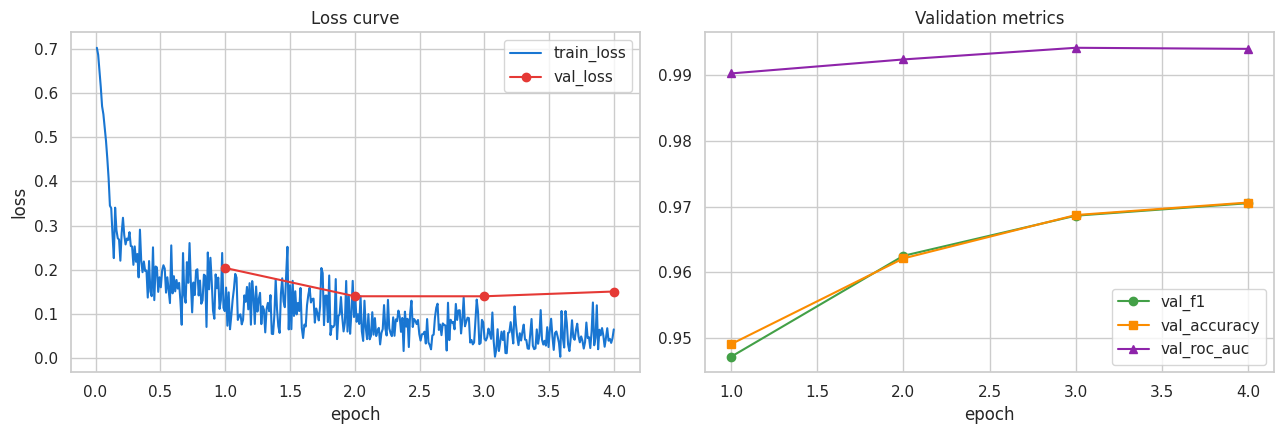

In [9]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [(h['epoch'], h['loss']) for h in history if 'loss' in h and 'eval_loss' not in h]
eval_rows = [(h['epoch'], h.get('eval_loss'), h.get('eval_f1'), h.get('eval_accuracy'), h.get('eval_roc_auc')) for h in history if 'eval_loss' in h]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
if train_loss:
    e, v = zip(*train_loss)
    axes[0].plot(e, v, label='train_loss', color='#1976d2')
if eval_rows:
    e, vl, *_ = zip(*eval_rows)
    axes[0].plot(e, vl, label='val_loss', color='#e53935', marker='o')
axes[0].set_title('Loss curve')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()

if eval_rows:
    e, _, f1s, accs, aucs = zip(*eval_rows)
    axes[1].plot(e, f1s, label='val_f1', marker='o', color='#43a047')
    axes[1].plot(e, accs, label='val_accuracy', marker='s', color='#fb8c00')
    axes[1].plot(e, aucs, label='val_roc_auc', marker='^', color='#8e24aa')
    axes[1].set_title('Validation metrics')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'training_curves.png', dpi=150)
plt.show()

## 9. Evaluation on Test set + charts

Includes: Confusion matrix, ROC curve, Precision-Recall curve, classification report (precision/recall/F1).

Evaluating on Validation set to find optimal threshold for FPR <= 5%...


Optimized Threshold for FPR <= 5%: 0.0086 (Val FPR=0.0494, Val TPR=0.9806)


              precision    recall  f1-score   support

   benign(0)     0.9746    0.9586    0.9665      3403
 phishing(1)     0.9592    0.9750    0.9671      3403

    accuracy                         0.9668      6806
   macro avg     0.9669    0.9668    0.9668      6806
weighted avg     0.9669    0.9668    0.9668      6806



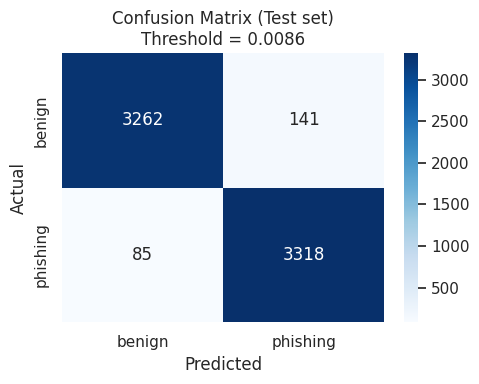

In [10]:
import numpy as np
import torch
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

# -- NEW: Threshold optimization on Validation Set for FPR <= 5% --
print("Evaluating on Validation set to find optimal threshold for FPR <= 5%...")
val_preds_out = trainer.predict(val_ds)
val_labels = val_preds_out.label_ids
val_probs = torch.softmax(torch.tensor(val_preds_out.predictions), dim=-1).numpy()[:, 1]
fpr_val, tpr_val, thresholds_val = roc_curve(val_labels, val_probs)

target_fpr = 0.05
valid_indices = np.where(fpr_val <= target_fpr)[0]
best_idx = valid_indices[-1] if len(valid_indices) > 0 else 0
best_threshold = float(thresholds_val[best_idx])
print(f"Optimized Threshold for FPR <= 5%: {best_threshold:.4f} (Val FPR={fpr_val[best_idx]:.4f}, Val TPR={tpr_val[best_idx]:.4f})")

# -- Evaluation on Test set --
preds_out = trainer.predict(test_ds)
logits = preds_out.predictions
labels = preds_out.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

# Use optimized threshold instead of 0.5
preds = (probs >= best_threshold).astype(int)

report_text = classification_report(labels, preds, target_names=['benign(0)', 'phishing(1)'], digits=4)
print(report_text)
(OUTPUT_REPORT_DIR / 'classification_report.txt').write_text(report_text, encoding='utf-8')

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['benign', 'phishing'], yticklabels=['benign', 'phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test set)\nThreshold = {best_threshold:.4f}')
plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

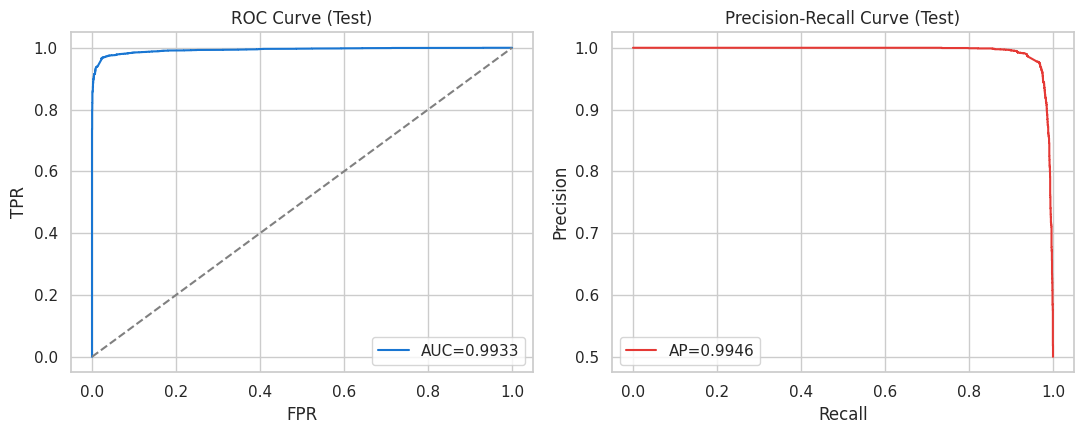

In [11]:
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(labels, probs)
ap = average_precision_score(labels, probs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f'AUC={roc_auc:.4f}', color='#1976d2')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curve (Test)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

axes[1].plot(rec, prec, label=f'AP={ap:.4f}', color='#e53935')
axes[1].set_title('Precision-Recall Curve (Test)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'roc_pr_curves.png', dpi=150)
plt.show()

## 10. Save model + tokenizer + summary report

The model is saved to Drive at `Project3_Models/xlmr_phishing/`. You can load it back using `AutoModelForSequenceClassification.from_pretrained(...)` to use it in the extension/API.

In [12]:
import json

trainer.save_model(str(OUTPUT_MODEL_DIR))
tokenizer.save_pretrained(str(OUTPUT_MODEL_DIR))

summary = {
    'model_name': MODEL_NAME,
    'max_length': MAX_LEN,
    'epochs': args.num_train_epochs,
    'class_weights': class_weights_np.tolist(),
    'split_sizes': {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)},
    'optimized_threshold': float(best_threshold),
    'test_metrics': {
        'accuracy': float((preds == labels).mean()),
        'roc_auc': float(roc_auc),
        'average_precision': float(ap),
    },
    'output_model_dir': str(OUTPUT_MODEL_DIR),
    'output_report_dir': str(OUTPUT_REPORT_DIR),
}
with (OUTPUT_REPORT_DIR / 'summary.json').open('w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
summary

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'model_name': 'xlm-roberta-base',
 'max_length': 256,
 'epochs': 4,
 'class_weights': [0.9999685158365342, 1.0000314861460957],
 'split_sizes': {'train': 31761, 'val': 6806, 'test': 6806},
 'optimized_threshold': 0.008628875948488712,
 'test_metrics': {'accuracy': 0.9667940052894505,
  'roc_auc': 0.9933004525142419,
  'average_precision': 0.9945683257553505},
 'output_model_dir': '/kaggle/working/models/xlmr_phishing',
 'output_report_dir': '/kaggle/working/reports/xlmr_phishing'}

## 11. (Optional) Test Inference

The cell below loads the model from Drive and predicts on 5 random test samples for a quick visual check.

In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tok = AutoTokenizer.from_pretrained(str(OUTPUT_MODEL_DIR))
mdl = AutoModelForSequenceClassification.from_pretrained(str(OUTPUT_MODEL_DIR)).to(device).eval()

samples = test_df.sample(min(5, len(test_df)), random_state=0)
with torch.no_grad():
    enc = tok(list(samples['text_combined']), truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt').to(device)
    logits = mdl(**enc).logits
    probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
for fid, lab, p in zip(samples['file_id'], samples['label'], probs):
    pred = int(p >= best_threshold)
    mark = '✅' if pred == lab else '❌'
    print(f'{mark} file_id={fid} true={lab} pred={pred} prob_phishing={p:.3f}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ file_id=1_8842 true=1 pred=1 prob_phishing=1.000
✅ file_id=0_17114 true=0 pred=0 prob_phishing=0.000
✅ file_id=1_26304 true=1 pred=1 prob_phishing=1.000
✅ file_id=1_30327 true=1 pred=1 prob_phishing=1.000
✅ file_id=1_14854 true=1 pred=1 prob_phishing=1.000


## 12. (Optional) Hyperparameter Tuning with Optuna

This section demonstrates how to use Optuna for hyperparameter search. Since it trains multiple models, it takes a long time. You can enable it if needed.

In [14]:
# !pip install optuna
# def model_init():
#     return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
#
# hyper_trainer = WeightedTrainer(
#     model_init=model_init,
#     args=args,
#     train_dataset=train_ds,
#     eval_dataset=val_ds,
#     compute_metrics=compute_metrics,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )
#
# def optuna_hp_space(trial):
#     return {
#         "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
#         "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
#         "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.1)
#     }
#
# best_run = hyper_trainer.hyperparameter_search(
#     direction="maximize",
#     backend="optuna",
#     hp_space=optuna_hp_space,
#     n_trials=5
# )
# print('Best Run:', best_run)
